<h1 style="color:magenta;">NSL - Exercises 12 </h1>

### 28/5/2026
### Giulia Federica Bianca Coppi (84486A)

## Ex 12.1

In this exercise, I evaluated the performance of a DNN on the MNIST dataset, comparing three different optimization algorithms: **Stochastic Gradient Descent (SGD)**, **Adam**, and **Adamax**. The network was trained over 40 epochs with a batch size of 128, utilizing a 50% Dropout layer before the output to prevent overfitting.

* **Adam and Adamax:** both adaptive optimizers exhibit very fast convergence. Within the first 15 epochs, the training accuracy sharpens rapidly and the validation loss drops abruptly. This efficiency is due to their ability to dynamically scale the learning rate for each individual parameter based on past gradients and moments. In their hyperparameters, I explicitly reduced the learning rates to 0.0001 (for Adam) and 0.0002 (for Adamax): without this tuning, the trajectories would have been far more unstable and would have rapidly incurred overfitting
* **SGD:** standard SGD shows a much slower, linear learning trajectory. Because it utilizes a fixed, uniform learning rate, it requires significantly more epochs to navigate the loss surface and reach comparable accuracy levels

Thanks to the parameters imposed, the validation curves remain stable and the network shows no signs of overfitting. In the next exercises, I therefore chose to use the Adamax optimizer with a learning rate of 0.0002, 40 epochs, and a batch size of 64.

In [46]:
import tensorflow as tf
from tensorflow import keras
import os
import numpy as np
import matplotlib.pyplot as plt
seed=0
np.random.seed(seed) # fix random seed
tf.random.set_seed(seed)

In [47]:
from keras.datasets import mnist

# input image dimensions
img_rows, img_cols = 28, 28 # number of pixels 
# output
num_classes = 10 # 10 digits

# the data, split between train and test sets
(X_train, Y_train), (X_test, Y_test) = mnist.load_data()

# reshape data, it could depend on Keras backend
X_train = X_train.reshape(X_train.shape[0], img_rows*img_cols)
X_test = X_test.reshape(X_test.shape[0], img_rows*img_cols)

# cast to floats
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

# rescale data in interval [0,1]      fondamentale nelle reti neurali, se non normalizzo non riesco ad allenare!
X_train /= 255
X_test /= 255

## convert class vectors to binary class matrices, e.g. for use with categorical_crossentropy
Y_train = keras.utils.to_categorical(Y_train, num_classes)
Y_test = keras.utils.to_categorical(Y_test, num_classes)


Optimizer = SGD


Test loss, {optimizer_name}: 0.08368248492479324
Test accuracy {optimizer_name}: 0.9732999801635742
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


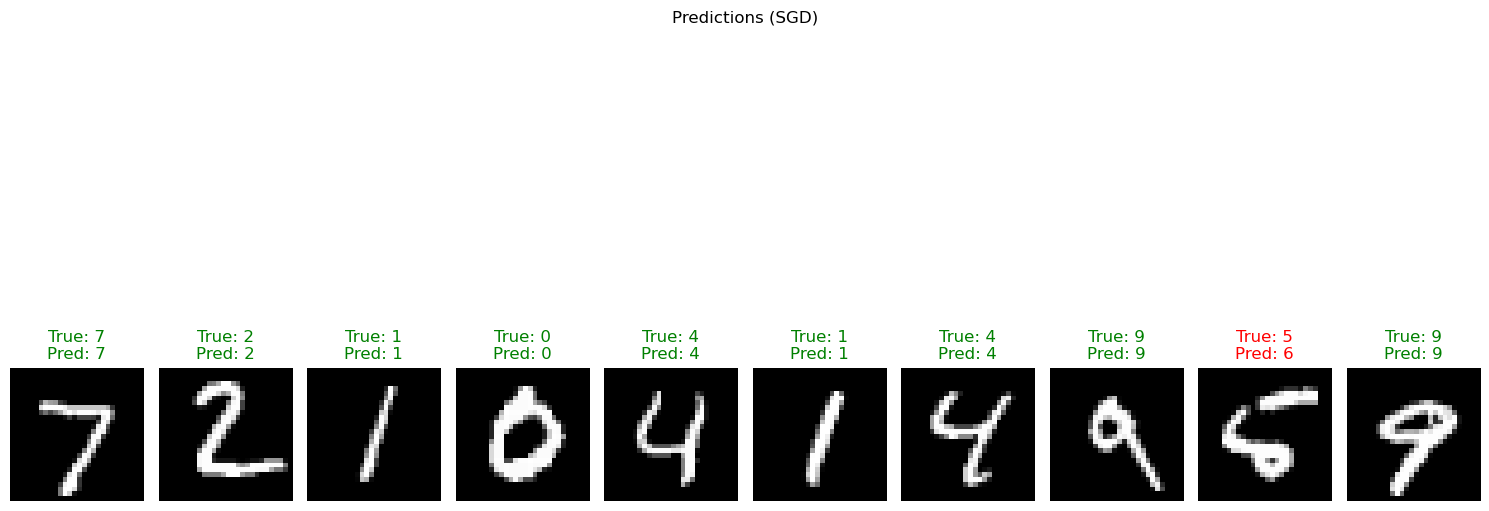


Optimizer = Adam


Test loss, {optimizer_name}: 0.06878769397735596
Test accuracy {optimizer_name}: 0.9811000227928162
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


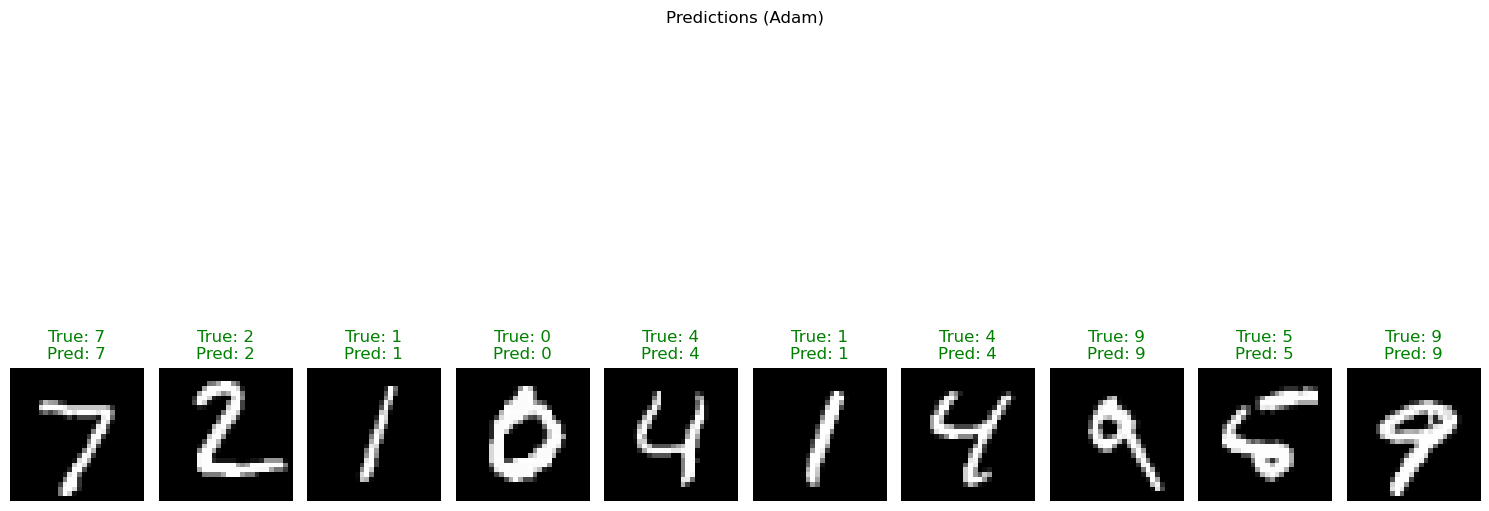


Optimizer = Adamax


Test loss, {optimizer_name}: 0.07805885374546051
Test accuracy {optimizer_name}: 0.9753999710083008
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


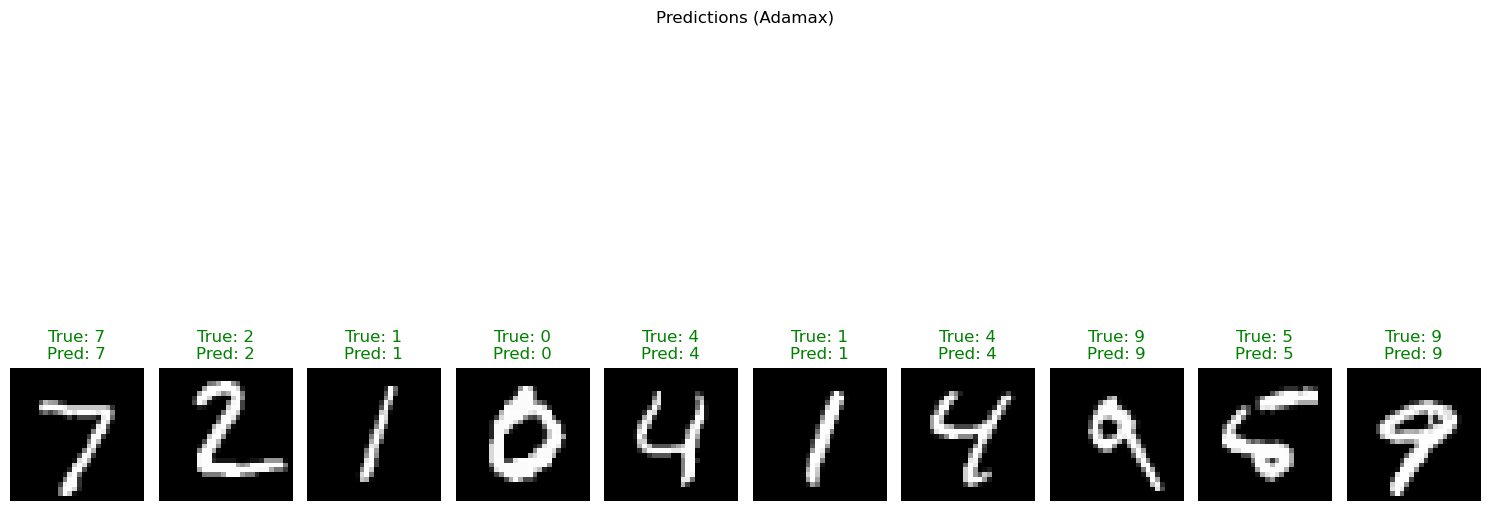

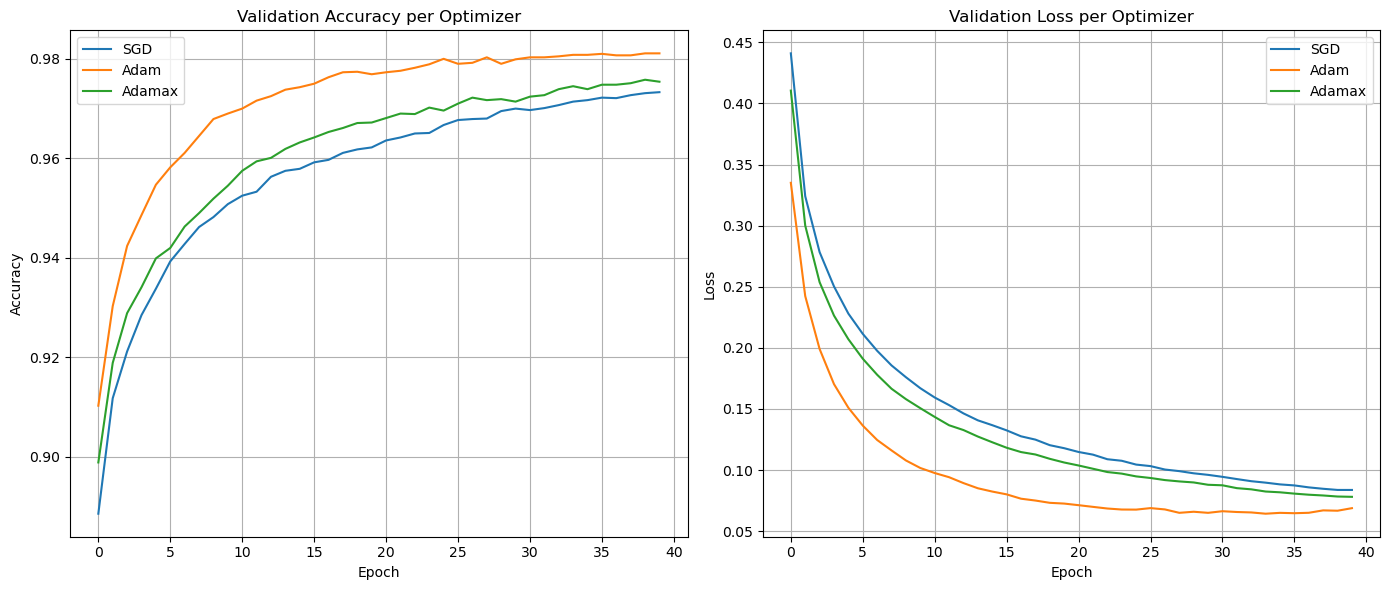

In [48]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, Input #dropout è lo spegnimento casuale di alcuni layer per aiutarla a generalizzare
from keras.optimizers import SGD, Adam, Adamax

def create_DNN():
    # instantiate model
    model = Sequential()
    model.add(Input(shape=(img_rows*img_cols,)))
    # add a dense all-to-all relu layer
    model.add(Dense(200, activation='relu'))
    # add a dense all-to-all relu layer
    model.add(Dense(100, activation='relu'))
    # apply dropout with rate 0.5
    model.add(Dropout(0.5))
    # soft-max layer
    model.add(Dense(num_classes, activation='softmax'))
    
    return model

#Optimizers = SGD, Adam, Nandam
opt = [('SGD', SGD()), ('Adam', Adam(learning_rate=0.0001)), ('Adamax', Adamax(learning_rate=0.0002))]

#training parameters
batch_size = 64
epochs = 40
history_plots = {}

for optimizer_name, optimizer in opt:
    print(f"\nOptimizer = {optimizer_name}\n")
    
    # create the model
    model=create_DNN()
    # compile the model
    model.compile(loss=keras.losses.categorical_crossentropy,
                  optimizer=optimizer,
                  metrics=['acc'])

    # train DNN and store training info in history
    history = model.fit(X_train, Y_train,
              batch_size=batch_size,
              epochs=epochs,
              shuffle=True, # a good idea is to shuffle input before at each epoch
              verbose=0,
              validation_data=(X_test, Y_test))

    history_plots[optimizer_name]=history

    # evaluate model
    score = model.evaluate(X_test, Y_test, verbose=0)

    # print performance
    print()
    print('Test loss, {optimizer_name}:', score[0])
    print('Test accuracy {optimizer_name}:', score[1])

    # Predictions X_test
    predictions = model.predict(X_test)
    
    X_test_view = X_test.reshape(X_test.shape[0], img_rows, img_cols)

    plt.figure(figsize=(15, 15))
    for i in range(10):
        ax = plt.subplot(2, 10, i + 1)
        plt.imshow(X_test_view[i], cmap='gray')
        true_label = np.argmax(Y_test[i])
        predicted_label = np.argmax(predictions[i])
        color = 'green' if true_label == predicted_label else 'red'
        plt.title(f'True: {true_label}\nPred: {predicted_label}', color=color)
        plt.axis('off')
    plt.suptitle(f'Predictions ({optimizer_name})')
    plt.tight_layout()
    plt.show()


# look into training history

# summarize history for accuracy
plt.figure(figsize=(14, 6))


plt.subplot(1, 2, 1)
for optimizer_name in history_plots:
    plt.plot(history_plots[optimizer_name].history['val_acc'], label=optimizer_name)
plt.title('Validation Accuracy per Optimizer')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.grid(True)
plt.legend(loc='best') # Mostra i veri nomi: SGD, Adam, Adamax

# summarize history for loss
plt.subplot(1, 2, 2)
for optimizer_name in history_plots:
    plt.plot(history_plots[optimizer_name].history['val_loss'], label=optimizer_name)
plt.title('Validation Loss per Optimizer')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.grid(True)
plt.legend(loc='best')

plt.tight_layout()
plt.show()


## Ex 12.2

In this exercise, I implemented a Deep Convolutional Neural Network to exploit the spatial correlations and translational invariance intrinsic to the MNIST image dataset. The architecture was structured as follows:
1. **First Convolutional Layer:** 10 filters with a $5 \times 5$ kernel size and relu activation, receiving the 3D input shape $(28, 28, 1)$
2. **First Max Pooling Layer:** $2 \times 2$ pool size to reduce the spatial dimensions by half
3. **Second Convolutional Layer:** 16 filters with a $5 \times 5$ kernel size and relu activation
4. **Second Max Pooling Layer:** $2 \times 2$ pool size
5. **Classification Head:** a `Flatten` layer transitioning the remaining 3D volume into a 1D vector, followed by a `Dense` layer with 128 neurons (relu), a $50\%$ `Dropout` layer for regularization, and a final 10-class `Dense` output layer with Softmax activation

Based on the hyperparameter tuning explored in the previous exercise, the model was trained over 40 epochs using the **Adamax** optimizer and a batch size of 64 to ensure optimal convergence.

The DCNN achieves outstanding performance, rapidly reaching a validation accuracy superior to $98-99\%$, outperforming the standard fully connected DNN from Exercise 12.1. This demonstrates the physical efficiency of incorporating local feature extractors (the convolution kernels) that scan for local geometric patterns regardless of their specific absolute position in the pixel grid.

Unlike the fully connected network, the CNN possesses a drastically reduced number of total trainable parameters due to weight sharing across the image space. Consequently, reducing the learning rate too aggressively (0.0002 as before) would lock the filters in a suboptimal state, preventing efficient learning within 40 epochs. Restoring a balanced learning rate of 0.001 combined with a batch size of 128 allowed the network to smoothly descend the loss surface toward a deep global minimum.

Thanks to the spatial downsampling performed by the `MaxPooling2D` layers and the regularizing action of the `Dropout(0.5)` layer, the validation loss curve displays an extremely stable, asymptotic behavior. There is no sign of overfitting, showing that the network retains excellent generalization capabilities even when pushed to 40 epochs.

In [49]:
import tensorflow as tf
from tensorflow import keras
import os
import numpy as np
import matplotlib.pyplot as plt
seed=0
np.random.seed(seed) # fix random seed
tf.random.set_seed(seed)

In [50]:
from keras.datasets import mnist

# input image dimensions
img_rows, img_cols = 28, 28 # number of pixels 
# output
num_classes = 10 # 10 digits

# the data, split between train and test sets
(X_train, Y_train), (X_test, Y_test) = mnist.load_data()

# reshape data, it could depend on Keras backend
X_train = X_train.reshape(X_train.shape[0], img_rows*img_cols)
X_test = X_test.reshape(X_test.shape[0], img_rows*img_cols)

# cast to floats
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

# rescale data in interval [0,1]      fondamentale nelle reti neurali, se non normalizzo non riesco ad allenare!
X_train /= 255
X_test /= 255

## convert class vectors to binary class matrices, e.g. for use with categorical_crossentropy
Y_train = keras.utils.to_categorical(Y_train, num_classes)
Y_test = keras.utils.to_categorical(Y_test, num_classes)

In [51]:
# you will need the following for Convolutional Neural Networks
from keras.models import Sequential
from keras.layers import Dense, Dropout, Input #dropout è lo spegnimento casuale di alcuni layer per aiutarla a generalizzare
from keras.layers import Flatten, Conv2D, MaxPooling2D

# reshape data, depending on Keras backend
if keras.backend.image_data_format() == 'channels_first':
    X_train = X_train.reshape(X_train.shape[0], 1, img_rows, img_cols)
    X_test = X_test.reshape(X_test.shape[0], 1, img_rows, img_cols)
    input_shape = (1, img_rows, img_cols)
else:
    X_train = X_train.reshape(X_train.shape[0], img_rows, img_cols, 1)
    X_test = X_test.reshape(X_test.shape[0], img_rows, img_cols, 1)
    input_shape = (img_rows, img_cols, 1)
    
print('X_train shape:', X_train.shape)
print('Y_train shape:', Y_train.shape)
print()
print(X_train.shape[0], 'train samples')
print(X_test.shape[0], 'test samples')

X_train shape: (60000, 28, 28, 1)
Y_train shape: (60000, 10)

60000 train samples
10000 test samples


In [52]:
#THIS IS INCOMPLETE ... COMPLETE BEFORE EXECUTING IT

def create_CNN():
    # instantiate model
    model = Sequential()
    # add first convolutional layer with 10 filters (dimensionality of output space)
    model.add(Conv2D(10, kernel_size=(5, 5),
                     activation='relu',
                     input_shape=input_shape))
    #
    # ADD HERE SOME OTHER LAYERS AT YOUR WILL, FOR EXAMPLE SOME: Dropout, 2D pooling, 2D convolutional etc. ... 
    # remember to move towards a standard flat layer in the final part of your DNN,
    # and that we need a soft-max layer with num_classes=10 possible outputs
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Conv2D(filters=16, 
                 kernel_size=(5, 5), 
                 activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(10, activation='softmax'))
    # compile the model
    model.compile(loss=keras.losses.categorical_crossentropy,
                  optimizer='Adamax',
                  metrics=['acc'])
    return model

In [53]:
# training parameters
batch_size = 64
epochs = 40 # INSERT HERE AN ADEQUATE NUMBER OF EPOCHS!

# create the deep conv net
model_CNN=create_CNN()

# train CNN
history = model_CNN.fit(X_train, Y_train,
              batch_size=batch_size,
              epochs=epochs,
              shuffle=True,
              verbose=1,
              validation_data=(X_test, Y_test))

# evaliate model
score = model_CNN.evaluate(X_test, Y_test, verbose=1)

# print performance
print()
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Epoch 1/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - acc: 0.8415 - loss: 0.5194 - val_acc: 0.9563 - val_loss: 0.1480
Epoch 2/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - acc: 0.9404 - loss: 0.2004 - val_acc: 0.9714 - val_loss: 0.0939
Epoch 3/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - acc: 0.9564 - loss: 0.1505 - val_acc: 0.9765 - val_loss: 0.0732
Epoch 4/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - acc: 0.9621 - loss: 0.1259 - val_acc: 0.9803 - val_loss: 0.0623
Epoch 5/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - acc: 0.9663 - loss: 0.1104 - val_acc: 0.9824 - val_loss: 0.0549
Epoch 6/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - acc: 0.9714 - loss: 0.0976 - val_acc: 0.9836 - val_loss: 0.0511
Epoch 7/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - acc: 0.9726 - loss: 0.0905 - val_acc: 0.9847 - val_loss: 0.0472
Epoch 8/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - acc: 0.9753 - loss: 0.0842 - val_acc: 0.9861 - val_loss: 0.0451
Epoch 9/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - ac

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.9919 - loss: 0.0259

Test loss: 0.02589285559952259
Test accuracy: 0.9919000267982483


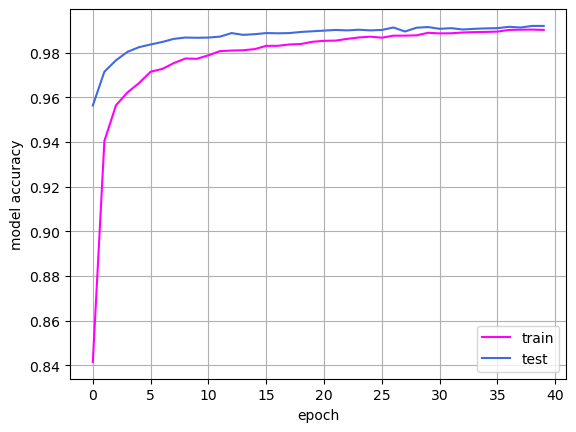

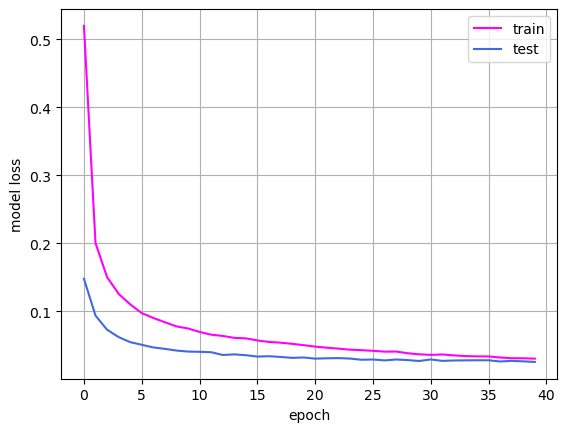

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


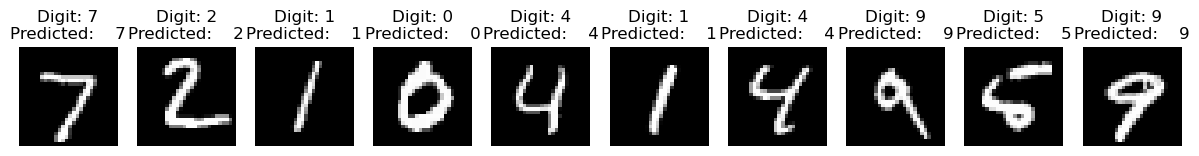

In [54]:
# evaluate model
score = model_CNN.evaluate(X_test, Y_test, verbose=1)

# print performance
print()
print('Test loss:', score[0])
print('Test accuracy:', score[1])

# look into training history

# summarize history for accuracy
plt.plot(history.history['acc'], color = 'magenta')
plt.plot(history.history['val_acc'], color = 'royalblue')
plt.ylabel('model accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='best')
plt.grid()
plt.show()

# summarize history for loss
plt.plot(history.history['loss'], color = 'magenta')
plt.plot(history.history['val_loss'], color = 'royalblue')
plt.ylabel('model loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='best')
plt.grid()
plt.show()

#X_test = X_test.reshape(X_test.shape[0], img_rows*img_cols)
predictions = model_CNN.predict(X_test)

X_test = X_test.reshape(X_test.shape[0], img_rows, img_cols,1)

plt.figure(figsize=(15, 15)) 
for i in range(10):    
    ax = plt.subplot(2, 10, i + 1)    
    plt.imshow(X_test[i, :, :, 0], cmap='gray')    
    plt.title("Digit: {}\nPredicted:    {}".format(np.argmax(Y_test[i]), np.argmax(predictions[i])))    
    plt.axis('off') 
plt.show()

## Ex 12.3 - Testing on Custom Handwritten Digits

In this final section, both models were tested against a custom dataset of 10 digits hat I created using GIMP, processed to match the MNIST format (28x28 pixels, normalized, and inverted to white stroke on a black background).

While the CNN achieved a theoretical validation accuracy higher than $98\%$ during training, testing it on real-world, custom-generated data highlighted some limitations: slight translations or off-center positioning and slight drawing defects in drawings drastically alter the activation maps of the first convolutional layers, leading to misclassifications;


### DNN

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


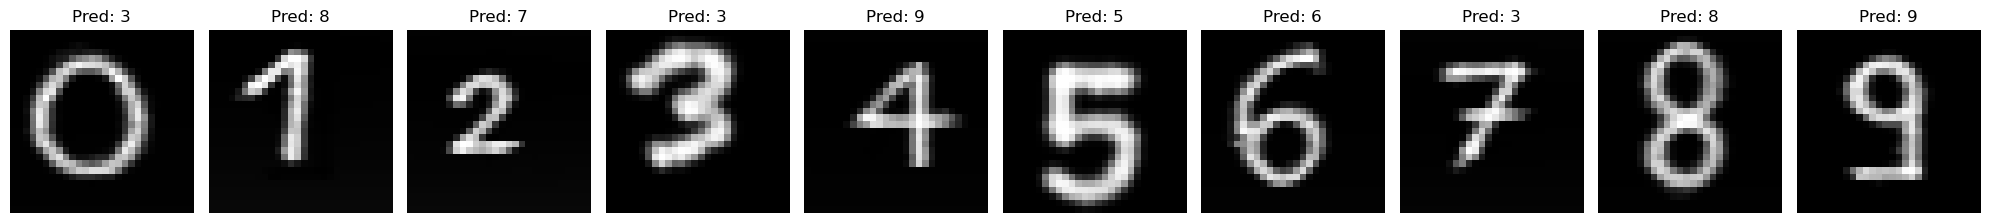

In [55]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

digits = []
images = []

for n in range(10):
    digit_filename = f"{n}.png"
    digit_in = Image.open(digit_filename).convert('L')
    xdim, ydim = digit_in.size
    pix = digit_in.load()
    data = np.zeros((xdim, ydim))
    for j in range(ydim):
        for i in range(xdim):
            data[i, j] = pix[j, i]
    data /= 255
    digits.append(data)                  
    images.append(data.reshape(-1))       # 1D DNN

# Convertili in array NumPy per batch prediction
X = np.array(images) # shape: (10, xdim * ydim)

predictions = model.predict(X)
predicted_digits = np.argmax(predictions, axis=1)

plt.figure(figsize=(20, 2.5))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(digits[i], cmap='gray')
    plt.title(f"Pred: {predicted_digits[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

### CNN

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


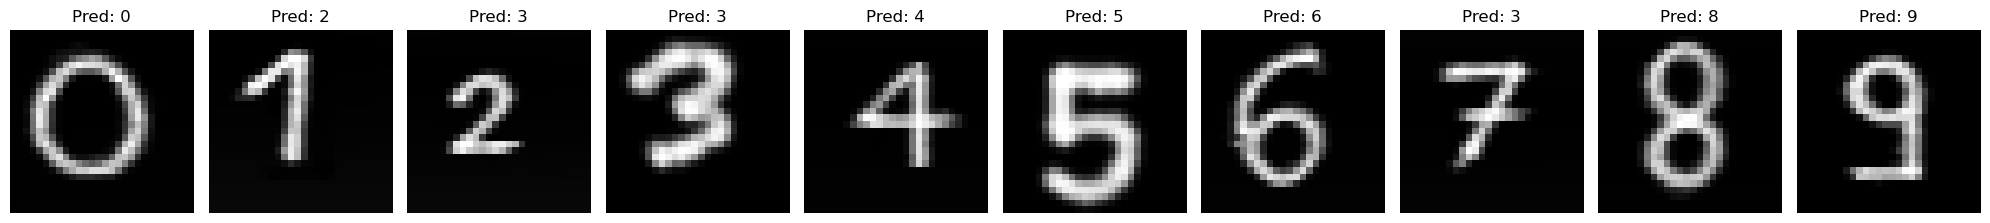

In [56]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

digits = []

for n in range(10):
    digit_filename = f"{n}.png"
    digit_in = Image.open(digit_filename).convert('L')
    xdim, ydim = digit_in.size
    pix = digit_in.load()
    data = np.zeros((xdim, ydim))
    for j in range(ydim):
        for i in range(xdim):
            data[i, j] = pix[j, i]
    data /= 255
    digits.append(data)                  

# Convertili in array NumPy per batch prediction
X = np.array(digits)   # shape: (10, xdim * ydim)
X = X.reshape(10, 28, 28, 1)

predictions = model_CNN.predict(X)
predicted_digits = np.argmax(predictions, axis=1)

plt.figure(figsize=(20, 2.5))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(digits[i], cmap='gray')
    plt.title(f"Pred: {predicted_digits[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()